In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
BATCH_SIZE = 128
NUM_EPOCHS = 30
LEARNING_RATE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
NUM_CLASSES = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')

Using downloaded and verified file: ./data\cifar-10-python.tar.gz
Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Training samples : 50000
Test samples     : 10000


In [5]:
VGG19_CONFIG = [
    64, 64, 'M',
    128, 128, 'M',
    256, 256, 256, 256, 'M',
    512, 512, 512, 512, 'M',
    512, 512, 512, 512, 'M'
]
class VGG19(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG19, self).__init__()
        self.features = self._make_layers(VGG19_CONFIG)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes))
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                layers += [
                    nn.Conv2d(in_channels, v, kernel_size=3, padding=1),
                    nn.BatchNorm2d(v),
                    nn.ReLU(inplace=True)
                ]
                in_channels = v
        return nn.Sequential(*layers)

model = VGG19(num_classes=NUM_CLASSES).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

VGG19(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 2

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [7]:
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss':  [], 'test_acc':  []}
best_acc = 0.0
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'vgg19_best.pth')
    elapsed = time.time() - t0
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] 'f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  'f'Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.2f}%  'f'Time: {elapsed:.1f}s')
print(f'\nBest test accuracy: {best_acc:.2f}%')

Epoch [01/30] Train Loss: 1.6976  Train Acc: 34.25%  Test Loss: 1.5414  Test Acc: 45.24%  Time: 35.4s
Epoch [02/30] Train Loss: 1.2249  Train Acc: 57.15%  Test Loss: 1.0095  Test Acc: 64.91%  Time: 35.7s
Epoch [03/30] Train Loss: 0.9569  Train Acc: 68.02%  Test Loss: 0.8917  Test Acc: 70.94%  Time: 36.9s
Epoch [04/30] Train Loss: 0.8057  Train Acc: 73.48%  Test Loss: 0.7023  Test Acc: 76.55%  Time: 35.7s
Epoch [05/30] Train Loss: 0.6988  Train Acc: 77.24%  Test Loss: 0.7370  Test Acc: 75.55%  Time: 36.2s
Epoch [06/30] Train Loss: 0.6366  Train Acc: 79.40%  Test Loss: 0.6949  Test Acc: 77.23%  Time: 36.6s
Epoch [07/30] Train Loss: 0.5802  Train Acc: 81.36%  Test Loss: 0.5563  Test Acc: 81.96%  Time: 36.3s
Epoch [08/30] Train Loss: 0.5300  Train Acc: 82.97%  Test Loss: 0.5664  Test Acc: 81.95%  Time: 36.5s
Epoch [09/30] Train Loss: 0.4844  Train Acc: 84.50%  Test Loss: 0.5305  Test Acc: 82.40%  Time: 34.7s
Epoch [10/30] Train Loss: 0.4447  Train Acc: 85.68%  Test Loss: 0.4680  Test Acc: 

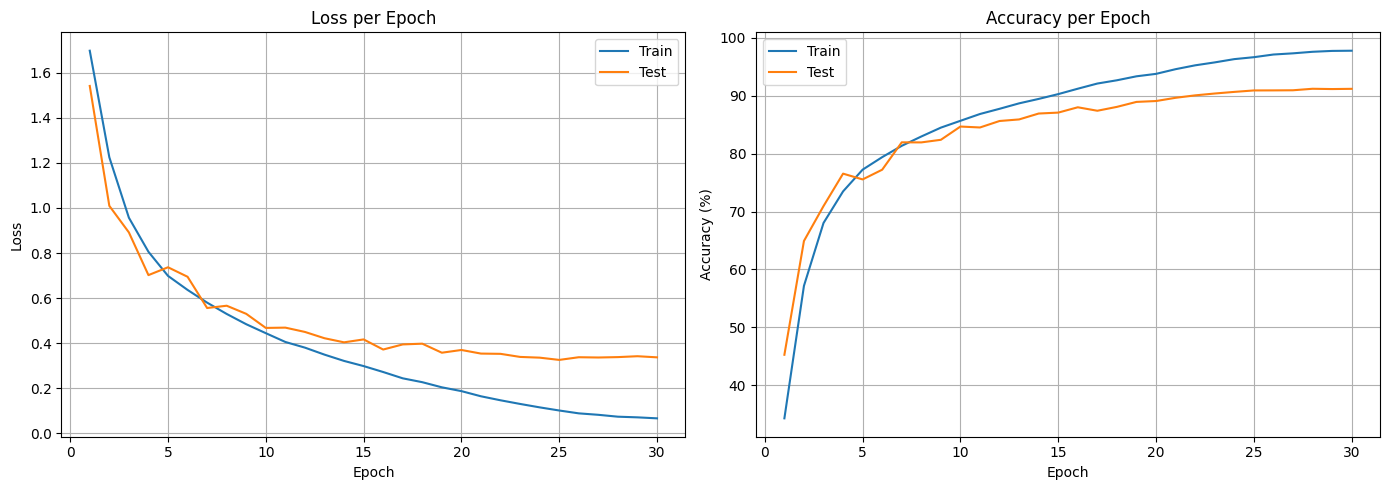

In [8]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['test_loss'],  label='Test')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['test_acc'],  label='Test')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [9]:
model.load_state_dict(torch.load('vgg19_best.pth', map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Final Test Loss     : {test_loss:.4f}')
print(f'Final Test Accuracy : {test_acc:.2f}%')

Final Test Loss     : 0.3385
Final Test Accuracy : 91.22%


In [10]:
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        correct_mask = predicted.eq(labels)
        for i in range(labels.size(0)):
            lbl = labels[i].item()
            class_correct[lbl] += correct_mask[i].item()
            class_total[lbl]   += 1
print('Per-class accuracy:')
for i, cls in enumerate(classes):
    acc = 100.0 * class_correct[i] / class_total[i]
    print(f'  {cls:<8s}: {acc:.2f}%')

Per-class accuracy:
  plane   : 92.80%
  car     : 96.60%
  bird    : 87.20%
  cat     : 80.80%
  deer    : 91.70%
  dog     : 85.40%
  frog    : 94.30%
  horse   : 93.10%
  ship    : 94.80%
  truck   : 95.50%


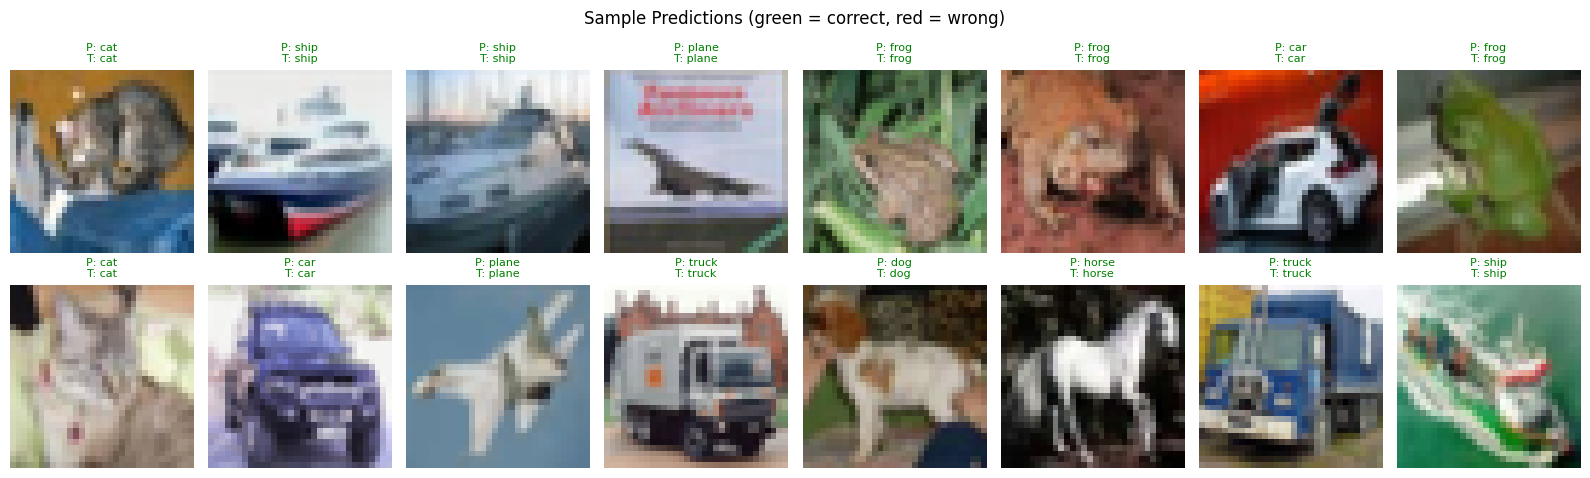

In [11]:
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])
def denormalize(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)
dataiter = iter(test_loader)
images, labels = next(dataiter)
model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = outputs.max(1)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]))
    pred_lbl  = classes[preds[i].item()]
    true_lbl  = classes[labels[i].item()]
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(f'P: {pred_lbl}\nT: {true_lbl}', fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Sample Predictions (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)

def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

def compute_metrics(y_true, y_pred, model_name='Model', class_names=None):
    acc  = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    rec_macro  = recall_score   (y_true, y_pred, average='macro',    zero_division=0)
    f1_macro   = f1_score       (y_true, y_pred, average='macro',    zero_division=0)
    prec_w     = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_w      = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
    f1_w       = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
    print(f'  {model_name} – Classification Metrics')
    print('='*50)
    print(f'  Accuracy           : {acc*100:.2f}%')
    print(f'  Precision (macro)  : {prec_macro:.4f}')
    print(f'  Recall    (macro)  : {rec_macro:.4f}')
    print(f'  F1-Score  (macro)  : {f1_macro:.4f}')
    print(f'  Precision (weighted): {prec_w:.4f}')
    print(f'  Recall    (weighted): {rec_w:.4f}')
    print(f'  F1-Score  (weighted): {f1_w:.4f}')
    if class_names:
        print(f'\nPer-class report:')
        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return dict(
        accuracy=acc,
        precision_macro=prec_macro, recall_macro=rec_macro, f1_macro=f1_macro,
        precision_weighted=prec_w, recall_weighted=rec_w, f1_weighted=f1_w)

In [18]:
model.load_state_dict(torch.load('vgg19_best.pth', map_location=device))
y_true_vgg, y_pred_vgg = get_all_predictions(model, test_loader, device)
metrics_vgg = compute_metrics(y_true_vgg, y_pred_vgg,
                               model_name='VGG19',
                               class_names=list(classes))

  VGG19 – Classification Metrics
  Accuracy           : 91.22%
  Precision (macro)  : 0.9122
  Recall    (macro)  : 0.9122
  F1-Score  (macro)  : 0.9121
  Precision (weighted): 0.9122
  Recall    (weighted): 0.9122
  F1-Score  (weighted): 0.9121

Per-class report:
              precision    recall  f1-score   support

       plane       0.91      0.93      0.92      1000
         car       0.97      0.97      0.97      1000
        bird       0.89      0.87      0.88      1000
         cat       0.82      0.81      0.82      1000
        deer       0.88      0.92      0.90      1000
         dog       0.86      0.85      0.85      1000
        frog       0.95      0.94      0.94      1000
       horse       0.95      0.93      0.94      1000
        ship       0.95      0.95      0.95      1000
       truck       0.94      0.95      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.

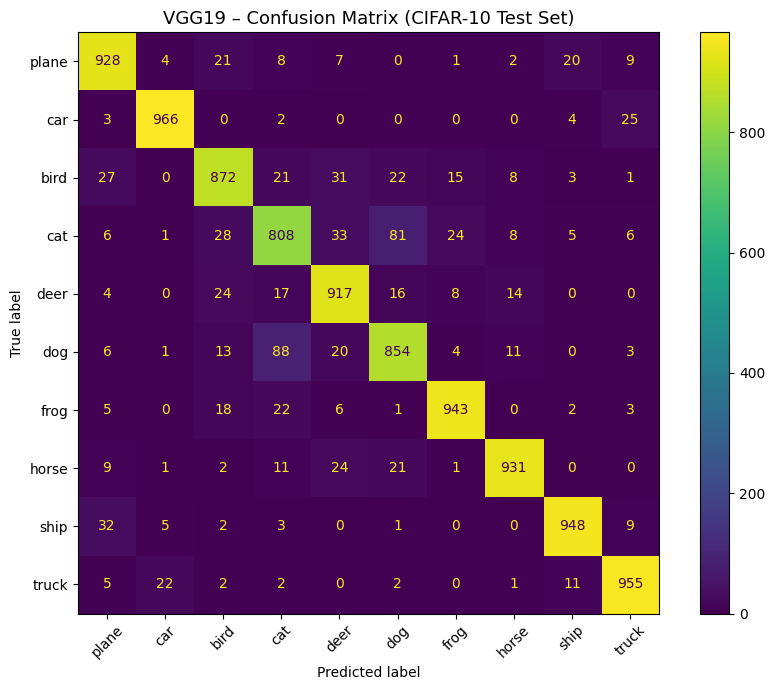

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=classes)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title('VGG19 – Confusion Matrix (CIFAR-10 Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('vgg19_confusion_matrix.png', dpi=150)
plt.show()